# Instruction of the code
## The code include three  function
* rotate
* skew
* result
## How to run the code
`result(path_name)`
* use "path's name" as the input and call result

In [1]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


## Part 1

In [2]:
#import libraries
import numpy as np
import math
from PIL import Image
import cv2
import matplotlib.pyplot as plt

In [3]:
def rotate(image,theta,clockwise=True):
    width, height,_ = image.shape
    if clockwise:
        theta=-theta
        
    if theta<0:
        theta+=360
    #preprocessing the image avoinding have negative sin and cos
    #after flipping the image as keeping their starting theta from their quadrant
    #the theta value can always keep in (0,90)
    if theta > 90 and theta<=180:
        img=np.zeros((height, width, 3), dtype=np.uint8)
        theta=theta-90
        for y in range(height):
            for x in range(width):
                img[y, x, :] = image[x, height - y - 1, :]
    elif theta>180 and theta <=270:
        img=np.zeros((width, height, 3), dtype=np.uint8)
        theta=theta-180
        for y in range(height):
            for x in range(width):
                img[width-x-1, height-y-1, :]=image[x,y,:]
    elif theta>270 and theta<360:
        img=np.zeros((height, width, 3), dtype=np.uint8)
        theta=theta-270
        for y in range(height):
            for x in range(width):
                #img[height-y-1, x, :] = image[x, y, :]
                img[y, x, :] = image[width-x-1, y, :]
    else:
        img=image
        
    height,width,_=img.shape
    ang=np.radians(theta)
    c,s=np.cos(ang),np.sin(ang)
    

    new_height,new_width=round(height*c+width*s),round(height*s+width*c)
    center=width//2,height//2
    new_center=new_width//2,new_height//2

    rotate_img=np.uint8(np.zeros((new_height,new_width,img.shape[2])))

    #rotate
    for j in range(new_height):
        for i in range(new_width):
            y=(j-new_center[1])*c+(i-new_center[0])*s
            x=(j-new_center[1])*(-s)+(i-new_center[0])*c

            y=round(y)+center[1]
            x=round(x)+center[0]

            if (y>=0 and x>=0 and y<img.shape[0] and  x<img.shape[1]):
                rotate_img[j,i,:]=img[y,x,:]
                
    return rotate_img

In [6]:
def skew(img,theta):
    #convert theta to radiance angle
    rad = math.radians(theta)
    width = round(img.shape[1]+img.shape[0]*(math.tan(rad)))
    skew_img = np.zeros((img.shape[0],width,3)).astype("uint8")
    #print(img.shape[0],width)
    for i in range(width):
        for j in range(img.shape[0]):
            org_x=i-(img.shape[0]-j)*math.tan(rad)
            org_y=j

            org_x=round(org_x)
            org_y=round(org_y)
            if 0<org_x < img.shape[1] and 0<org_y < img.shape[0]:
                skew_img[j,i,:]=img[org_y,org_x,:]
    return skew_img

## part2

In [10]:
def result(path_name):
    ######### part b
    img=cv2.imread(path_name)
    rotate_list=[30,60,120,-50]
    skew_list=[10,40,60]
    for theta in rotate_list:
        rotate_img=rotate(img,theta,clockwise=True)
        plt.figure()
        plt.imshow(cv2.cvtColor(rotate_img, cv2.COLOR_BGR2RGB))
        name="Clockwise "+str(theta)+" degree"
        plt.title(name)
    for theta in skew_list:
        skew_img=skew(img,theta)
        plt.figure()
        plt.imshow(cv2.cvtColor(skew_img, cv2.COLOR_BGR2RGB))
        name="Skew "+str(theta)+" degree"
        plt.title(name)
    ########## part c
    img=cv2.imread(path_name)
    rotate_img=rotate(img,20,clockwise=True)
    skew_img=skew(rotate_img,50)
    plt.figure()
    plt.imshow(cv2.cvtColor(skew_img, cv2.COLOR_BGR2RGB))
    plt.title("Rotate 20 -> Skew 20")
    ##
    skew_img=skew(img,50)
    rotate_img=rotate(skew_img,20,clockwise=True)
    plt.figure()
    plt.imshow(cv2.cvtColor(rotate_img, cv2.COLOR_BGR2RGB))
    plt.title("Skew 20 -> Rotate 50")

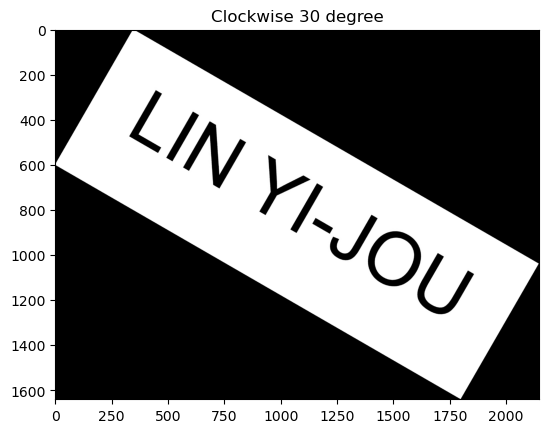

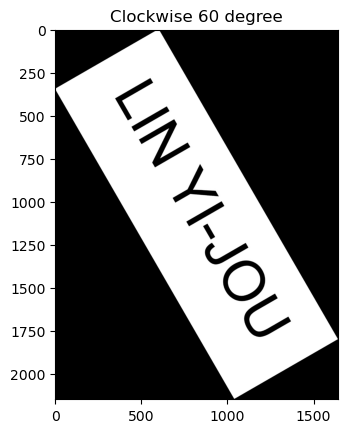

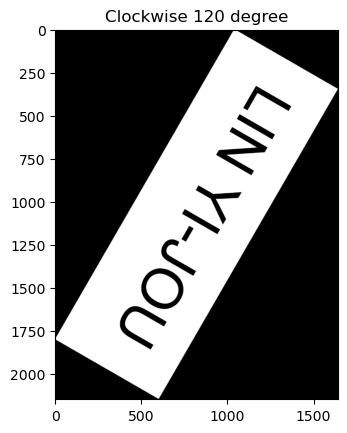

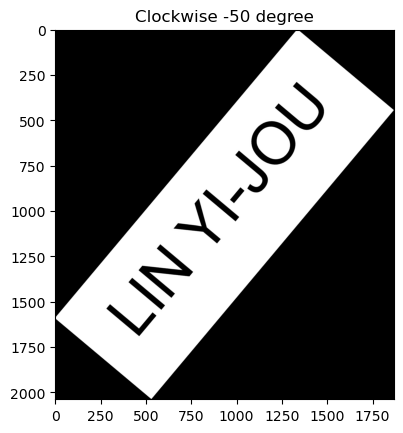

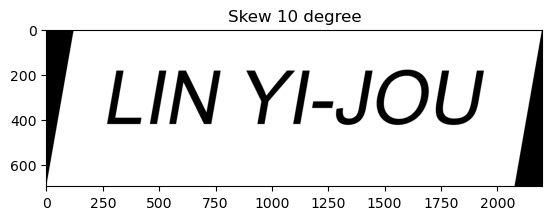

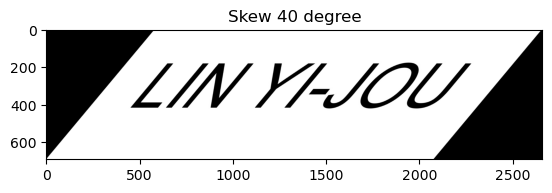

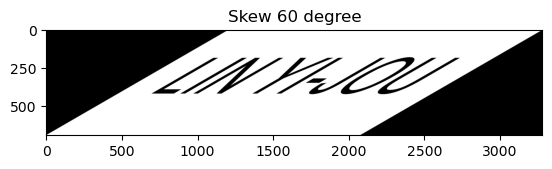

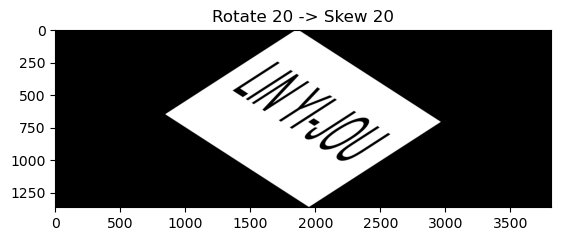

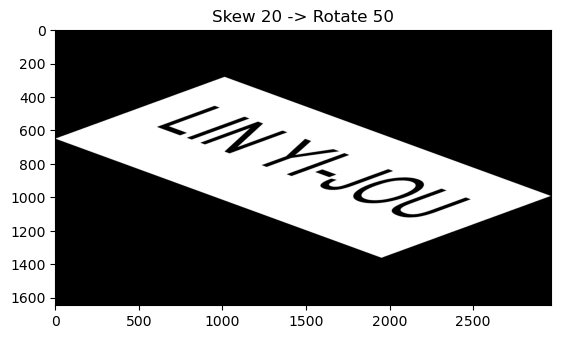

In [11]:
result("lin.jpg")